In [30]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

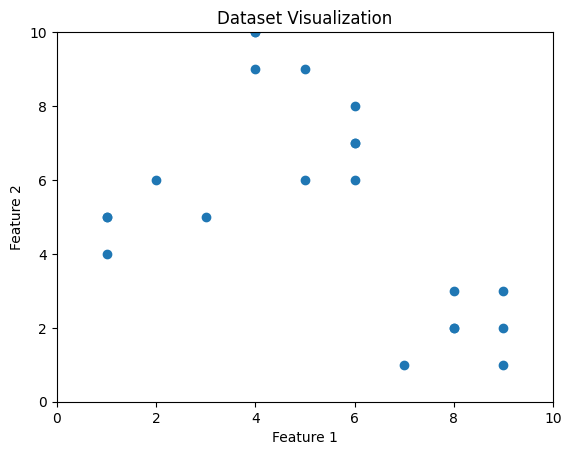

In [31]:
x1 = np.array([3, 1, 1, 2, 1, 6, 6, 6, 5, 6,
               7, 8, 9, 8, 9, 9, 8, 4, 4, 5, 4])
x2 = np.array([5, 4, 5, 6, 5, 8, 6, 7, 6, 7,
               1, 2, 1, 2, 3, 2, 3, 9, 10, 9, 10])
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)

plt.scatter(x1, x2, marker='o')
plt.xlim([0, 10])
plt.ylim([0, 10])
plt.title('Dataset Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [39]:
# distortion and inertia
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1,10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)

    distortions.append(sum(np.min(cdist(X,kmeanModel.cluster_centers_, 'euclidean'),axis=1)**2)/X.shape[0])

    inertias.append(kmeanModel.inertia_)

    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]



In [40]:
print(distortions)

[np.float64(14.90249433106576), np.float64(5.146258503401359), np.float64(1.8817838246409675), np.float64(0.856122448979592), np.float64(0.7166666666666667), np.float64(0.5484126984126984), np.float64(0.4325396825396825), np.float64(0.3817460317460318), np.float64(0.3341269841269841)]


In [41]:
print(inertias)

[312.95238095238096, 108.07142857142856, 39.51746031746031, 17.978571428571428, 15.05, 11.516666666666666, 9.083333333333332, 8.016666666666667, 7.0166666666666675]


In [42]:
print(mapping1)

{1: np.float64(14.90249433106576), 2: np.float64(5.146258503401359), 3: np.float64(1.8817838246409675), 4: np.float64(0.856122448979592), 5: np.float64(0.7166666666666667), 6: np.float64(0.5484126984126984), 7: np.float64(0.4325396825396825), 8: np.float64(0.3817460317460318), 9: np.float64(0.3341269841269841)}


In [43]:
print(mapping2)

{1: 312.95238095238096, 2: 108.07142857142856, 3: 39.51746031746031, 4: 17.978571428571428, 5: 15.05, 6: 11.516666666666666, 7: 9.083333333333332, 8: 8.016666666666667, 9: 7.0166666666666675}


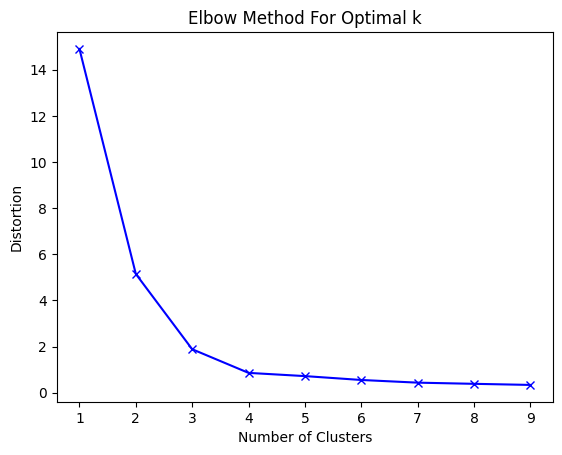

In [44]:
# distortion values
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method For Optimal k')
plt.show()

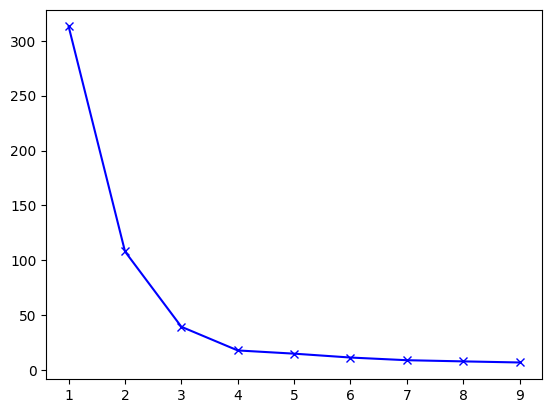

In [47]:
plt.plot(K,inertias,'bx-')